In [1]:
import numpy as np
import matplotlib.pyplot as plt
from plant.parameters import params
import sys, os
sys.path.append(os.path.abspath('..'))
from plant.battery import Uoc, coef_cubic,battery_step, thermal_model
from plant.powertrain import powertrain
from scipy.interpolate import RegularGridInterpolator

# Multi-lap Dynamic Programming with SoC repeatability constraint

Extends the single-lap DP to a full 5-lap race. The baseline (fuel-optimal, no
terminal SoC constraint) is shown to deplete charge within the first two laps,
causing a measurable power shortfall in the closing laps. Two soft-constraint
variants (fixed and lap-dependent SoC floor) are compared against this baseline.

**Inputs**: `data/multi_lap_Canada/Canada_5laps.npy`, `power_domand_multilap.npy`  \
**Outputs**: `u_star_baseline`, `u_star_fixed`, `u_star_var`, comparison plots \
**Depends on**: `plant/battery.py`, `plant/powertrain.py`

## 1. Formulate optimization problem (multi lap)

**Objective**

$$
\min \quad J = \sum_{k=0}^{N-1} \Big[ \dot{m}(k) + w_{sf}\, s(k) \Big] \Delta t,
\qquad
\dot{m}(k) = \frac{P_{ICE}(k) + P_{ICE,0}}{\eta_{ICE}\, H_{lhv}}
$$

where $s(k) = \max\big(P_{gb}(k) - P_{ICE}(k) - \eta_{MGU} P_2(k),\, 0\big)$ is the power
shortfall and $w_{sf} = 10^2$. The shortfall term is not a modelling nicety: without it the
optimizer is free to leave the power demand unmet at no cost, and the resulting policy is
fuel-optimal only because it does less work. The ablation in `01b_single_lap_DP_vectorized.ipynb`
quantifies this on a single lap.

Here $N$ is the number of samples over the whole race (all laps), not a single lap.
Let $\ell(k)$ denote the lap index of sample $k$.

**Control variable and unit convention**

The optimization variable is the **electrical** power at the battery terminals, $P_2$,
which is the quantity limited by regulation. The power-split constraints are **mechanical**,
and the two are related by the MGU-K efficiency with a direction-dependent conversion:

$$
P_{mech} = \eta_{MGU} P_2 \quad (P_2 > 0), \qquad
P_{mech} = \frac{P_2}{\eta_{MGU}} \quad (P_2 < 0)
$$

Every mechanical constraint is mapped into $P_2$ before entering the bounds.

**State dynamics**

$$
SoC(k+1) = SoC(k) - \frac{\Delta t}{Q_{bat} U_{oc}(SoC(k))}\, P_2(k)
$$

$$
E_{ES2K}(k+1) =
\begin{cases}
0, & \ell(k+1) > \ell(k) \quad \text{(new lap)} \\[4pt]
E_{ES2K}(k) + \max\big(P_2(k), 0\big)\, \Delta t, & \text{otherwise}
\end{cases}
$$

**Power balance**

$$
P_{gb}(k) =
\begin{cases}
P_{ICE}(k) + \eta_{MGU} P_2(k) + s(k), & P_{gb}(k) \ge 0 \\[4pt]
\dfrac{P_2(k)}{\eta_{MGU}} + P_{brake}(k), & P_{gb}(k) < 0
\end{cases}
$$

**Control bounds**

$$
\begin{cases}
\max\Big( \underline{P}_{SoC}(k),\, P_{MGU\text{-}K}^{min},\, \dfrac{P_{gb}(k) - P_{ICE}^{max}}{\eta_{MGU}} \Big)
\le P_2(k) \le
\min\Big( \overline{P}_{SoC}(k),\, \dfrac{E_{ES2K}^{max} - E_{ES2K}(k)}{\Delta t},\, P_{MGU\text{-}K}^{max},\, \dfrac{P_{gb}(k)}{\eta_{MGU}} \Big),
& P_{gb}(k) \ge 0 \\[14pt]
\max\Big( \underline{P}_{SoC}(k),\, P_{MGU\text{-}K}^{min},\, \eta_{MGU} P_{gb}(k) \Big)
\le P_2(k) \le \min\big( \overline{P}_{SoC}(k),\, 0 \big),
& P_{gb}(k) < 0
\end{cases}
$$

with the SoC-window limits

$$
\underline{P}_{SoC}(k) = \frac{(SoC^{max} - SoC(k))\,Q_{bat} U_{oc}(SoC(k))}{-\Delta t},
\qquad
\overline{P}_{SoC}(k) = \frac{(SoC^{min} - SoC(k))\,Q_{bat} U_{oc}(SoC(k))}{-\Delta t}
$$

When the interval is empty ($lb > ub$) the state is infeasible at that stage: the candidate
set collapses to zero power and the resulting gap is charged to the cost through $s(k)$.

**Component and regulatory limits**

$$
0 \le P_{ICE}(k) \le P_{ICE}^{max} = 400 \text{ kW}, \qquad P_{brake}(k) \le 0
$$

$$
0 \le \dot{m}(k) \le \dot{m}^{max} = 68.18 \text{ kg/h}, \qquad
0 \le E_{ES2K}(k) \le E_{ES2K}^{max} = 9 \text{ MJ}
$$

**Terminal condition**

$$
V(SoC, E_{ES2K}, N) = 0
$$

applied once, at the end of the race, not at the end of each lap.

In [2]:
#Define Parameters
dt = 0.1

Q_bat = params['E_pack_capacity']/params['V_oc_nom'] 

# Limits on Batt Power, Eng Power, SOC
P_MGU_K_min = params['P_MGU_min']   # -350[kW]
P_MGU_K_max = params['P_MGU_max']   # 350[kW]
P_eng_max = params['P_ICE_max']   # 400[kW]
eta_MGU = params['eta_MGU']

E_ES2K_max = params['E_deploy_max'] # 9[MJ]

SoC_min = params['SoC_min']     # 0.2[-]
SoC_max = params['SoC_max']     # 0.9[-]

eta_ICE = params['eta_ICE']     # 0.489
P_ICE0 = params['P_ICE0']       # 15[kW]
LHV = params['LHV']

data = np.load('/app/data/multi_lap_Canada/Canada_5laps.npy')

t = data[0,:]
N_lap = data[1,:] - 3 #the 3 laps starts from lap 3 to lap 7
v = data[2,:]
a = data[3,:]

power_data = np.load('data/multi_lap_Canada/power_domand_multilap.npy')

Pgb = power_data[1,:]


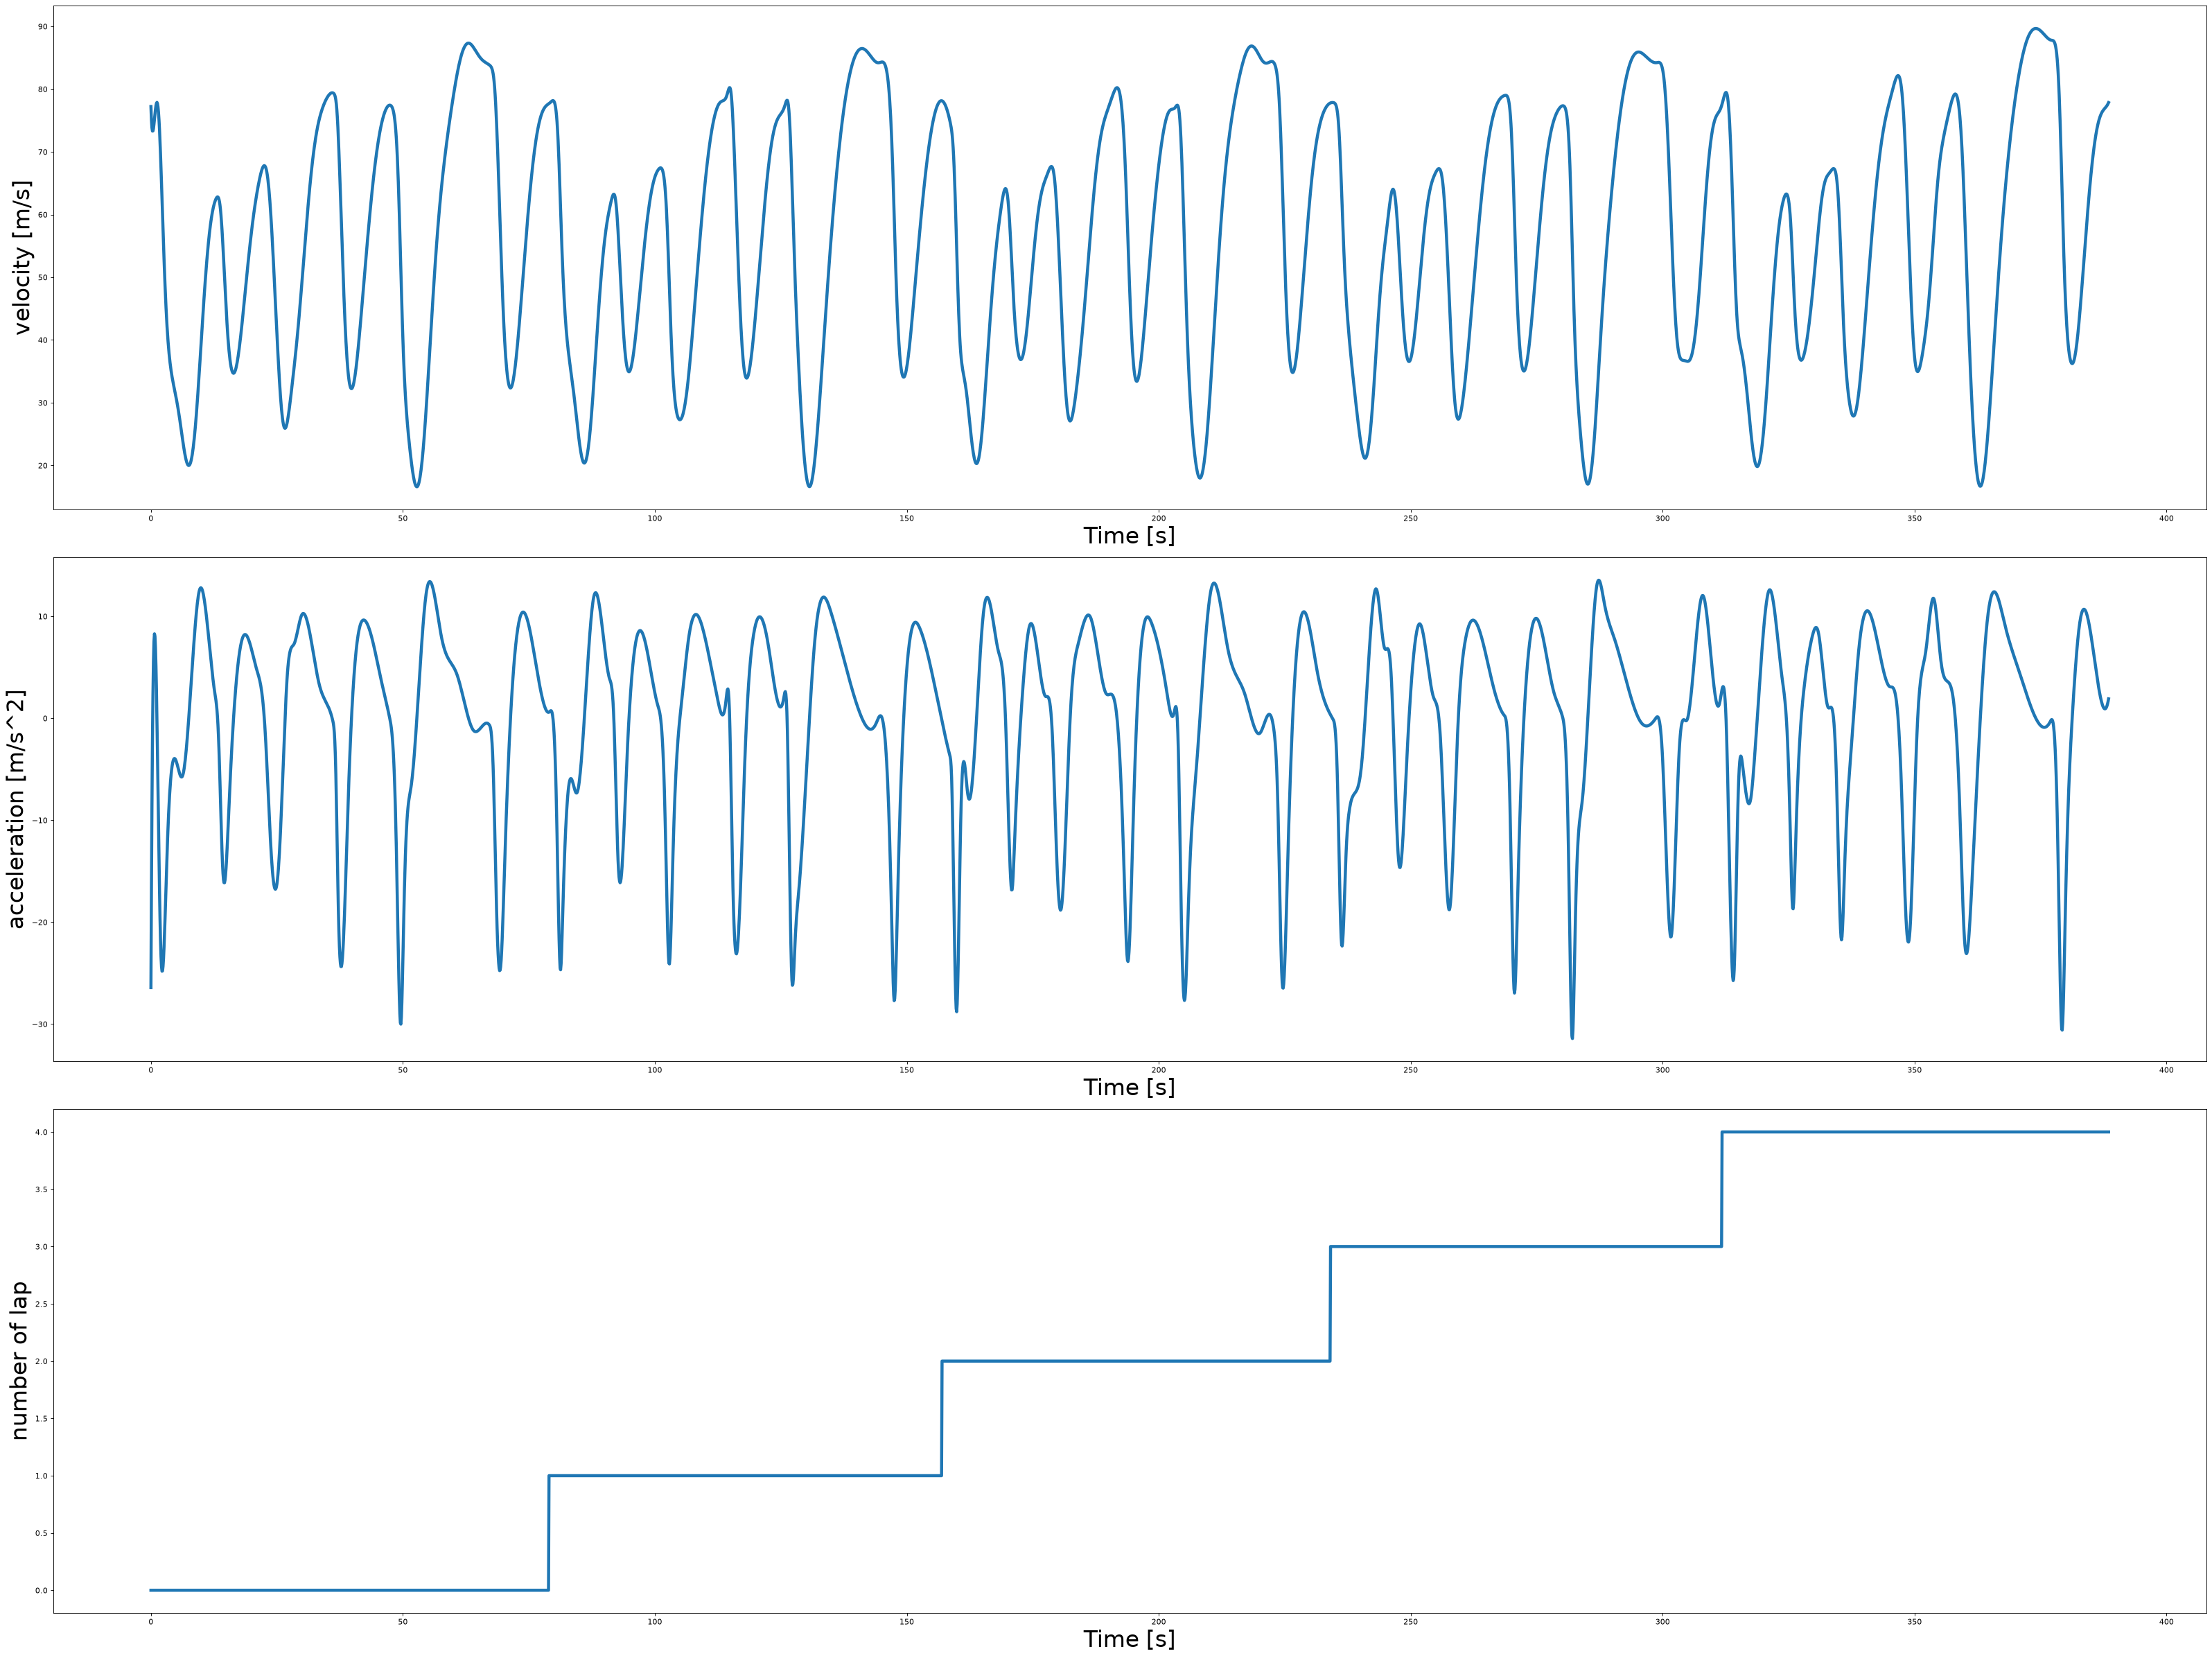

In [3]:
plt.figure(num=1, figsize=(40, 30), dpi=80, facecolor='w', edgecolor='k')

plt.subplot(3,1,1)
plt.plot(t,v, linewidth=4)
plt.xlabel('Time [s]', fontsize=30)
plt.ylabel('velocity [m/s]', fontsize=30)

plt.subplot(3,1,2)
plt.plot(t,a, linewidth=4)
plt.xlabel('Time [s]', fontsize=30)
plt.ylabel('acceleration [m/s^2]', fontsize=30)

plt.subplot(3,1,3)
plt.plot(t,N_lap, linewidth=4)
plt.xlabel('Time [s]', fontsize=30)
plt.ylabel('number of lap', fontsize=30)
plt.tight_layout()
plt.show()

In [4]:
SoC_grid = np.linspace(SoC_min,SoC_max, 80)
E_ES2K_grid = np.linspace(0,E_ES2K_max, 150)

#grid size
ns = len(SoC_grid)
ne = len(E_ES2K_grid)

#planning horizon (time steps)
N = len(t)
nu = 200

SoC_mesh,E_ES2K_mesh  = np.meshgrid(SoC_grid,E_ES2K_grid, indexing='ij')
SoC_max_term = (SoC_max-SoC_mesh)*Q_bat*Uoc(SoC_mesh,coef_cubic)/-dt
SoC_min_term = (SoC_min-SoC_mesh)*Q_bat*Uoc(SoC_mesh,coef_cubic)/-dt

E_ES2K_term = (E_ES2K_max-E_ES2K_mesh)/dt

## 2. Backward step

I now solve the DP backward in time over the whole race, from the last sample to the first. At each step k I build the feasible range for P_MGU-K(k) from the bounds above, evaluate the fuel cost for every candidate control, and combine it with the interpolated value function at k+1. The state that resets is E_ES2K, which must go back to zero at the start of every lap, since the deploy budget is a per lap quantity and cannot carry over. The terminal condition is applied only once, at the very last sample of the race.

In [5]:
def backward_step(SoC_target=None, beta=0.0):
    # Preallocate Value Function (rows index state, columns index time)
    V = np.inf*np.ones((ns,ne,N+1))
    #preollacate control (row index states, and columns index time)
    u_star = np.zeros_like(V)

    # Boundary Condition of Value Function (Principle of Optimality)
    if SoC_target is not None:
        if np.isscalar(SoC_target):
            target = SoC_target  
        else:
            target = SoC_target[int(N_lap[N-1])]
        V[:,:,N] = beta * np.maximum(0, target - SoC_mesh)**2
    else:
        V[:,:,N] = 0
    
    for k in range(N-1, -1, -1):
        interp_Vnext = RegularGridInterpolator((SoC_grid, E_ES2K_grid), V[:,:,k+1], bounds_error=False, fill_value=None)

        if Pgb[k]>=0:
            lb = np.maximum(SoC_max_term, np.maximum(P_MGU_K_min, (Pgb[k] - P_eng_max)/eta_MGU))
            ub = np.minimum(SoC_min_term,E_ES2K_term)
            ub = np.minimum(ub, np.minimum(P_MGU_K_max,Pgb[k]/eta_MGU))
        else:
            lb = np.maximum(SoC_max_term, np.maximum(P_MGU_K_min, Pgb[k]* eta_MGU))
            ub = np.minimum(SoC_min_term,0.0)
    
        infeasible_mask = lb > ub
        lb_safe = np.where(infeasible_mask, 0.0, lb)
        ub_safe = np.where(infeasible_mask, 0.0, ub)
        P_mgu_k_mesh = np.linspace(lb_safe,ub_safe,nu, axis=-1)

        if Pgb[k]>=0:
            P_ICE = np.clip(Pgb[k] - P_mgu_k_mesh*eta_MGU, 0, P_eng_max)
            shortfall = np.maximum(Pgb[k] - (P_ICE + P_mgu_k_mesh*eta_MGU), 0.0)
        else:
            P_ICE = np.zeros_like(P_mgu_k_mesh)
            shortfall = np.zeros_like(P_mgu_k_mesh)

        mdot = np.clip((P_ICE + P_ICE0)/(eta_ICE*LHV), 0, params['m_dot_max']/3600)

        # cost-per-time
        g_k = mdot*dt

        #compute the dynamics of the states
        Soc_next = SoC_mesh[:,:,np.newaxis] - dt*P_mgu_k_mesh/(Q_bat*Uoc(SoC_mesh[:,:,np.newaxis],coef_cubic))
        if k< N-1 and N_lap[k] < N_lap[k+1]:
            E_ES2K_next = np.zeros_like(Soc_next)
        else:
            E_ES2K_next = E_ES2K_mesh[:,:,np.newaxis] + np.maximum(0, P_mgu_k_mesh)*dt

        point = np.stack([Soc_next.ravel(), E_ES2K_next.ravel()], axis=-1)
        V_next = interp_Vnext(point).reshape(ns,ne,nu)

        G = g_k + V_next + 1e2*shortfall*dt
        V[:,:,k] = np.min(G, axis =-1) 
        ind = np.argmin(G, axis = -1)
        u_star[:,:,k] = np.take_along_axis(P_mgu_k_mesh, ind[:,:,np.newaxis], axis=-1).squeeze(axis=-1)

        if SoC_target is not None and k > 0 and N_lap[k-1] < N_lap[k]:
            lap_idx = int(N_lap[k])
            if np.isscalar(SoC_target):
                target = SoC_target 
            else:
                target=SoC_target[lap_idx]
            V[:,:,k] += beta * np.maximum(0, target - SoC_mesh)**2

    return V, u_star

## 3. Simulate optimal energy management results

Now that I've solved the DP over the full race, I can use the `u_star` map to
simulate the optimal strategy lap by lap, starting from a fully charged battery
(SoC_0 = 0.9).

In [6]:
V_baseline, u_star_baseline = backward_step(SoC_target=None, beta=0.0)

In [7]:
def foward_step(u, SoC_0, E_ES2K_0):
    SoC_sim = np.zeros(N)
    E_ES2K_sim = np.zeros(N)
    E_K2ES_sim = np.zeros(N)
    J_sim = np.zeros(N)
    P_eng_sim= np.zeros(N)
    P_mgu_k_sim =np.zeros(N)
    P_mech_MGU_K_real =np.zeros(N)
    m_dot_sim= np.zeros(N)
    Tbat_sim = np.zeros(N)



    SoC_sim[0] = SoC_0
    E_ES2K_sim[0] = E_ES2K_0
    E_K2ES_sim[0] = 0
    Tbat_sim[0] = params['T_bat_init']

    for k in range(0,(N-1)):
        interp_u = RegularGridInterpolator((SoC_grid,E_ES2K_grid),u[:,:,k], bounds_error=False, fill_value=None)
        point = np.array([[SoC_sim[k], E_ES2K_sim[k]]])
        P_mgu_k_sim[k] = interp_u(point)[0]

        P_eng_sim[k], P_elect_MGU_K,P_mech_MGU_K_real[k],_, E_ES2K_sim[k+1],E_K2ES_sim[k+1],m_dot_sim[k] = powertrain(Pgb[k],P_mgu_k_sim[k],E_ES2K_sim[k],E_K2ES_sim[k],params,dt, control_mode='P2')
        if N_lap[k+1] > N_lap[k]:
            E_ES2K_sim[k+1] = 0.0
            E_K2ES_sim[k+1] = 0.0
  
        SoC_sim[k+1], _,I2 = battery_step(SoC_sim[k],P_elect_MGU_K, coef_cubic, Tbat_sim[k],params,dt)
        Tbat_sim[k+1] = thermal_model(I2, Tbat_sim[k], params, dt)

        J_sim[k] = m_dot_sim[k]*dt


    return P_eng_sim,P_mech_MGU_K_real, E_ES2K_sim, E_K2ES_sim, SoC_sim,J_sim,Tbat_sim
SoC_init = 0.9
E_ES2K_init = 0.0
P_eng_sim90,P_mech_MGU_K_real90, E_ES2K_sim90, E_K2ES_sim, SoC_sim90,J_sim90, Tbat_sim90 = foward_step(u_star_baseline,SoC_init,E_ES2K_init)    

fuel_dp = np.sum(J_sim90) * 1e3  # g


np.save('/app/data/multi_lap_Canada/Temperature_battery.npy', np.stack([Tbat_sim90]))


## 4. Result analysis: tracking and shortfall

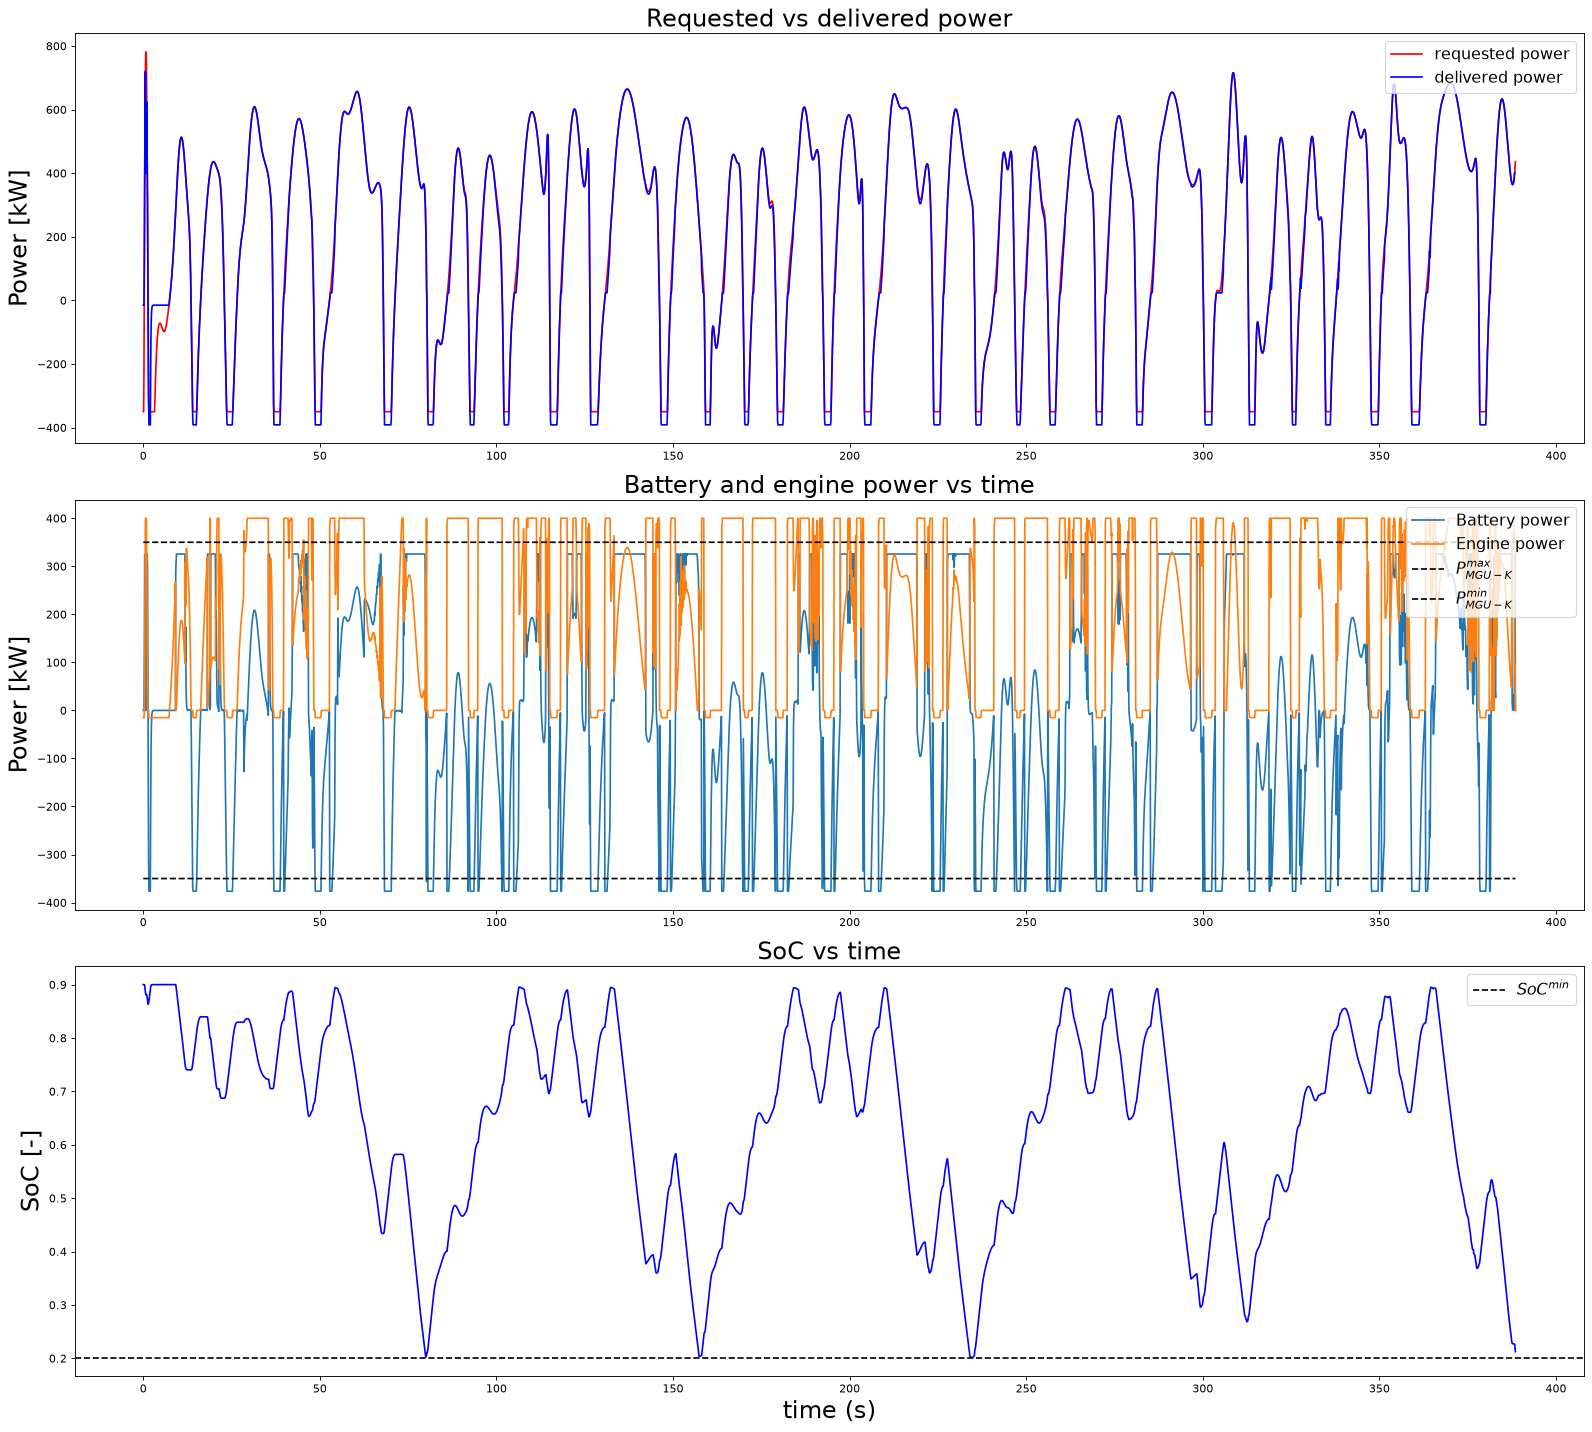

In [8]:
## Tracking analysis
for k in range(0,len(Pgb)):
    if Pgb[k] < P_MGU_K_min:
        Pgb[k] = P_MGU_K_min

fig, axs = plt.subplots(3, 1, figsize=(20, 18), dpi=80, facecolor='w', edgecolor='k')

axs[0].plot(t, Pgb/1e3, 'red', label='requested power')
axs[0].plot(t[0:-2], P_mech_MGU_K_real90[0:-2]/1e3 + P_eng_sim90[0:-2]/1e3, 'blue', label='delivered power')
axs[0].set_ylabel('Power [kW]', fontsize=22)
axs[0].set_title('Requested vs delivered power', fontsize=22)
axs[0].legend(loc=1, fontsize=14)

axs[1].plot(t, P_mech_MGU_K_real90/1e3, label='Battery power')
axs[1].plot(t, P_eng_sim90/1e3, label='Engine power')
axs[1].plot(t, P_MGU_K_max*np.ones(t.shape)/1e3, 'k--', label=r'$P_{MGU-K}^{max}$')
axs[1].plot(t, P_MGU_K_min*np.ones(t.shape)/1e3, 'k--', label=r'$P_{MGU-K}^{min}$')
axs[1].set_ylabel('Power [kW]', fontsize=22)
axs[1].set_title('Battery and engine power vs time', fontsize=22)
axs[1].legend(loc=1, fontsize=14)

axs[2].plot(t, SoC_sim90, 'blue')
axs[2].axhline(SoC_min, color='k', linestyle='--', label=r'$SoC^{min}$')
axs[2].set_xlabel('time (s)', fontsize=22)
axs[2].set_ylabel('SoC [-]', fontsize=22)
axs[2].set_title('SoC vs time', fontsize=22)
axs[2].legend(loc=1, fontsize=14)

plt.tight_layout()
plt.show()

The top plot compares requested and delivered power. Tracking is close over the whole
race, with the delivered trace departing from the request only in short, isolated
episodes rather than in a sustained band. The middle plot shows the split behind it:
the engine spends much of the race saturated at $P_{ICE}^{max}$, with the MGU-K
supplying the peaks above it and absorbing braking energy down to
$P_{MGU\text{-}K}^{min}$.

The bottom plot explains the structure of the strategy. SoC does not collapse once and
stay down: it cycles within every lap, starting from 0.9, drawing down through the lap,
and touching $SoC^{min}$ at the end of each of the five laps. The battery is being
fully cycled once per lap. This is the direct consequence of the 2026 energy-store
sizing: with roughly 4 MJ of usable storage against a 9 MJ per-lap deploy allowance, the
pack must be emptied and refilled within each lap for the deploy budget to be usable at
all.

The residual shortfall (1.792 MJ over the race) is distributed across the whole
duration rather than concentrated in the closing laps, appearing as isolated spikes of
a few tens of kW where the demand peaks coincide with a locally depleted battery. The
single large spike at $t = 0$ is an initial-condition artifact: the deploy budget starts
at zero and the first sample of the profile is a high-power transient.

This is already a markedly different picture from a formulation that ignores the
shortfall, where the optimizer drives SoC to the floor early and leaves the demand unmet
for long stretches. Penalizing the shortfall in the stage cost recovers most of the
feasibility on its own — which raises the question the next sections address: what is
left for an explicit end-of-lap constraint to fix?

## 5. Lap energy balance

To understand how the deploy budget is used across the race, I look at $E_{ES2K}$ (energy deployed within the current lap, reset to zero at every lap boundary) and $E_{K2ES}$ (cumulative regenerated energy) over time. This separates how much of the 9 MJ per lap budget is actually used from how much the battery recovers through braking, which is what the SoC trace alone cannot show directly.

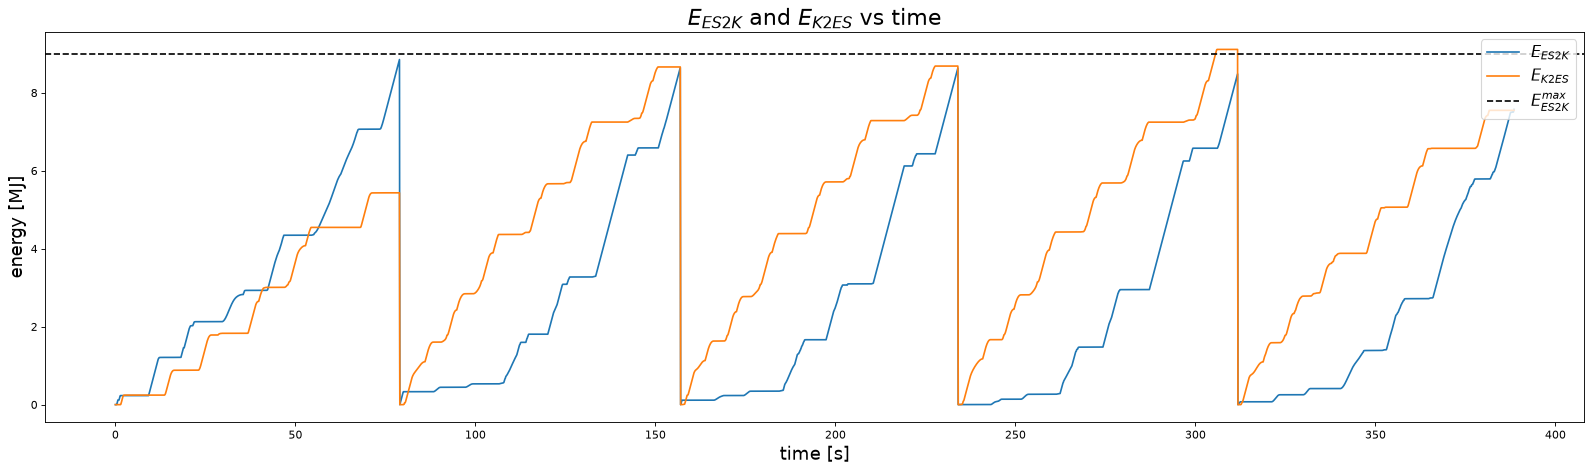

In [9]:
fig, ax = plt.subplots(figsize=(20, 6), dpi=80)
ax.plot(t, E_ES2K_sim90/1e6, label=r'$E_{ES2K}$')
ax.plot(t, E_K2ES_sim/1e6, label=r'$E_{K2ES}$')
ax.axhline(E_ES2K_max/1e6, linestyle='--', color='k', label=r'$E_{ES2K}^{max}$')
ax.set_xlabel('time [s]', fontsize=16)
ax.set_ylabel('energy [MJ]', fontsize=16)
ax.set_title(r'$E_{ES2K}$ and $E_{K2ES}$ vs time', fontsize=20)
ax.legend(loc=1, fontsize=14)
plt.tight_layout()
plt.show()

The lap-to-lap picture is more regular than the SoC trace alone suggests. $E_{ES2K}$
reaches 8.5–9 MJ in every lap, at or just below the regulatory ceiling, and laps 2, 3
and 4 are close to superimposable in both traces. Lap 1 is the outlier: starting from a
full battery, the strategy deploys early and recovers markedly less ($E_{K2ES}$ peaks
around 5.4 MJ against roughly 8.6 MJ in the following laps), because it begins with
stored energy it does not need to earn back. Lap 5 is truncated by the end of the race.

So the baseline is already largely repeatable from lap 2 onward, and the motivation for
an end-of-lap constraint is not the gross lap-to-lap variability that a shortfall-blind
formulation produces. It is narrower: SoC still reaches its floor at the end of every
lap, leaving no margin at the point where the next lap's first traction demand arrives,
and the residual shortfall is what that lack of margin costs.

## 6. Soft constraint on end of lap SoC

The baseline is fuel-optimal and, with the shortfall penalized, largely feasible. What it
does not do is leave any reserve: SoC arrives at $SoC^{min}$ at the end of every lap, so
the strategy enters each new lap with the battery empty and no margin for a demand peak
before regeneration has had time to refill it.

To leave that margin, a soft constraint is added on SoC at the end of every lap. Rather
than an equality target, an asymmetric hinge penalty is used, so that SoC values above the
target are never penalized and only values below it are pushed upward. This is deliberate:
an equality constraint would penalize the DP even when it ends a lap with more charge than
needed, which is never a feasibility problem, only a fuel inefficiency the cost function
already accounts for on its own. The one-sided penalty intervenes only where the baseline
actually runs out of margin, without discarding fuel savings that come at no cost to
consistency.

The penalty is added directly to the value function at every lap boundary, right after the
standard backward recursion has produced it, before the value is used by the previous time
step.

## 7. Three case comparison

Three variants are compared to quantify the trade off between fuel consumption and lap to lap repeatability.

Case 1, baseline: no constraint, the value function boundary condition is only $V(SoC, E_{ES2K}, N) = 0$ at the end of the race.

Case 2, fixed floor: a constant target $SoC_{target} = 0.7$ is enforced at the end of every lap.

Case 3, lap dependent floor: the target is kept low in the early laps and raised toward
the end of the race, on the hypothesis that the margin matters most once the cumulative
effect of repeated full cycles has built up. Whether that hypothesis holds is exactly what
the comparison below tests.

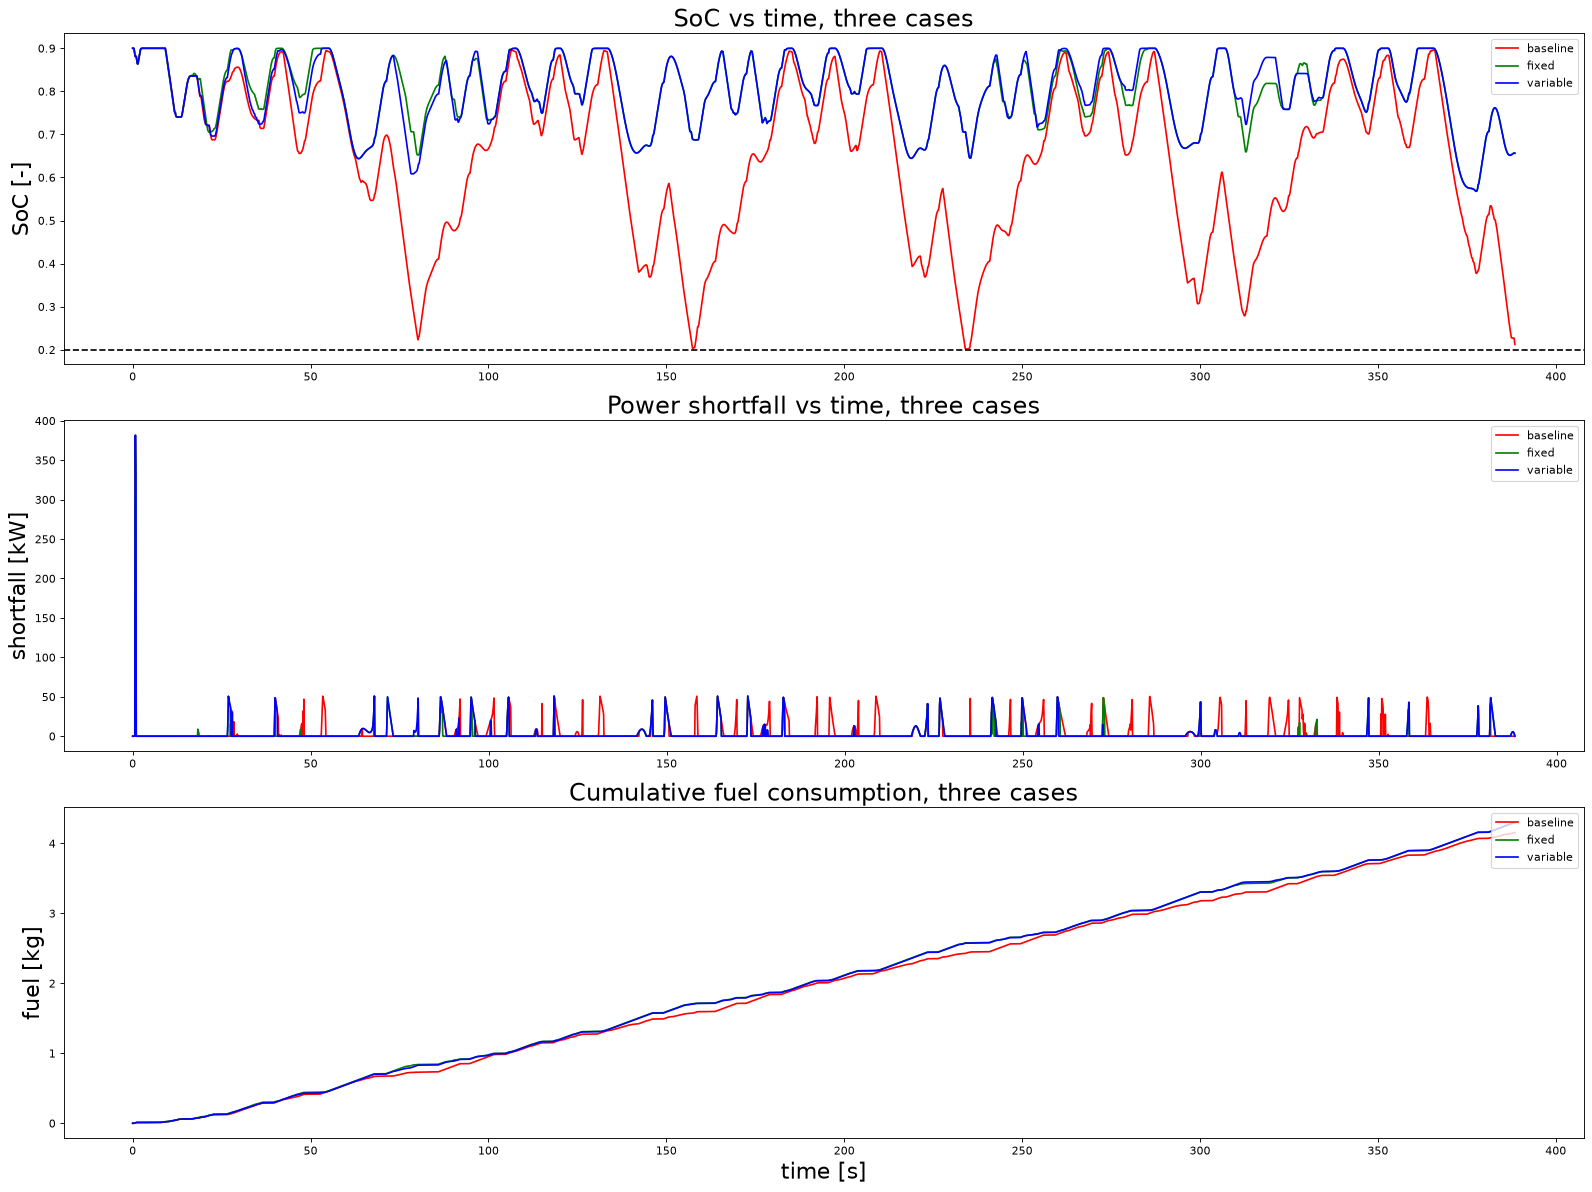

baseline: fuel = 4.1536 kg, shortfall energy = 1.792 MJ
fixed: fuel = 4.2978 kg, shortfall energy = 0.896 MJ
variable: fuel = 4.3001 kg, shortfall energy = 1.011 MJ


In [10]:
SoC_target_per_lap = np.array([0.6, 0.6, 0.7, 0.7, 0.8])

V_baseline, u_star_baseline = backward_step()
V_fixed,    u_star_fixed    = backward_step(SoC_target=0.7, beta=1e6)
V_var,      u_star_var      = backward_step(SoC_target=SoC_target_per_lap, beta=1e6)

results = {}
for name, u in [('baseline', u_star_baseline), ('fixed', u_star_fixed), ('variable', u_star_var)]:
    P_eng, P_mgu, E_ES2K, E_K2ES, SoC, J, Tbat = foward_step(u, SoC_0=0.9, E_ES2K_0=0.0)
    results[name] = dict(P_eng=P_eng, P_mgu=P_mgu, E_ES2K=E_ES2K, E_K2ES=E_K2ES, SoC=SoC, J=J, Tbat=Tbat)

fig, axs = plt.subplots(3, 1, figsize=(20, 15), dpi=80)
colors = {'baseline': 'red', 'fixed': 'green', 'variable': 'blue'}

for name in results:
    axs[0].plot(t, results[name]['SoC'], color=colors[name], label=name)
axs[0].axhline(SoC_min, color='k', linestyle='--')
axs[0].set_ylabel('SoC [-]', fontsize=20)
axs[0].set_title('SoC vs time, three cases', fontsize=22)
axs[0].legend(loc=1)

for name in results:
    delivered = results[name]['P_eng'] + results[name]['P_mgu']
    shortfall = np.maximum(0, Pgb - delivered)
    axs[1].plot(t[0:-2], shortfall[0:-2]/1e3, color=colors[name], label=name)
axs[1].set_ylabel('shortfall [kW]', fontsize=20)
axs[1].set_title('Power shortfall vs time, three cases', fontsize=22)
axs[1].legend(loc=1)

for name in results:
    axs[2].plot(t, np.cumsum(results[name]['J']), color=colors[name], label=name)
axs[2].set_xlabel('time [s]', fontsize=20)
axs[2].set_ylabel('fuel [kg]', fontsize=20)
axs[2].set_title('Cumulative fuel consumption, three cases', fontsize=22)
axs[2].legend(loc=1)

plt.tight_layout()
plt.show()

for name in results:
    total_fuel = np.sum(results[name]['J'])
    delivered = results[name]['P_eng'] + results[name]['P_mgu']
    total_shortfall_energy = np.sum(np.maximum(0, Pgb - delivered))*dt
    print(f"{name}: fuel = {total_fuel:.4f} kg, shortfall energy = {total_shortfall_energy/1e6:.3f} MJ")

Both soft-constraint variants do what they were introduced to do, and the trade-off is
clear:

| Case | Fuel [g] | Shortfall energy [MJ] |
|---|---|---|
| Baseline | 4153.63 | 1.792 |
| Fixed floor (0.7) | 4297.76 | 0.896 |
| Lap-dependent floor | 4300.05 | 1.011 |

The fixed floor halves the shortfall energy (−50.0%) for 144 g of extra fuel (+3.5%).
The SoC trace shows the mechanism directly: both constrained cases keep SoC above roughly
0.53 for the whole race instead of cycling down to the 0.2 floor, so the battery always
has usable charge when a traction peak arrives.

Between the two variants, the fixed floor wins on both axes: 0.896 MJ against 1.011 MJ of
shortfall, and 2.3 g less fuel. The fuel difference is below the resolution of the state
grid and should not be read as a ranking, but the 11% difference in shortfall energy is
not — the constant floor is genuinely the better of the two.

This is the opposite of the design intent behind Case 3. The lap-dependent schedule was
built on the assumption that the early laps need no margin and that relaxing the floor
there would buy back fuel. Neither half of that assumption survives: the residual shortfall
is distributed across the whole race rather than concentrated at the end, so relaxing the
floor early removes margin exactly where it is still being used, and the fuel saved by
relaxing it does not materialize because the constraint is not what dominates consumption.

The broader reading is that with the 2026 energy-store sizing the binding quantity is the
size of the store itself, not the placement of the end-of-lap target. A floor that is
uniform in time is enough to capture the available benefit; shaping it lap by lap adds a
tuning parameter without adding performance. The result is reported as found rather than
adjusted to match the original expectation.

In [11]:
os.makedirs('results', exist_ok=True)

np.savez('/app/data/results/multi_lap_comparison.npz',
    t=t, N_lap=N_lap, Pgb=Pgb,
    SoC_baseline=results['baseline']['SoC'], J_baseline=results['baseline']['J'],
    P_eng_baseline=results['baseline']['P_eng'], P_mgu_baseline=results['baseline']['P_mgu'],
    SoC_fixed=results['fixed']['SoC'], J_fixed=results['fixed']['J'],
    P_eng_fixed=results['fixed']['P_eng'], P_mgu_fixed=results['fixed']['P_mgu'],
    SoC_variable=results['variable']['SoC'], J_variable=results['variable']['J'],
    P_eng_variable=results['variable']['P_eng'], P_mgu_variable=results['variable']['P_mgu'],
)